# **SPECTRA-CQ: Classical Baseline Training (CAE)**
This notebook establishes the benchmark Mean Squared Error (MSE) reconstruction loss for the Classical Convolutional Autoencoder.

To ensure a strict ablation study against the upcoming Hybrid Quantum Autoencoder (HQAE), this classical model is artificially constrained to the exact same 3-seed, 15-epoch experimental protocol required by the quantum optimization landscape.

In [ ]:
from google.colab import drive
import os

# Mount Data Drive
drive.mount('/content/drive')

# Clone Github Repository
# Used a PAT here because the GitHub repo was private during our runs
# Scrubbed the actual token before downloading/documenting for security
GITHUB_TOKEN = "PAT"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 176 (delta 25), reused 93 (delta 16), pack-reused 73 (from 1)
Receiving objects: 100% (176/176), 32.48 MiB | 41.16 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25

#### **1. Hardware Verification**
The classical `Conv2d` and `ConvTranspose2d` layers require significant matrix multiplication capabilities.

Verify that the Colab runtime is successfully attached to the Nvidia T4 GPU before initiating the training loop.

In [2]:
import torch

if torch.cuda.is_available():
    print(f"Hardware Accelerator Confirmed: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("FATAL WARNING: GPU not detected. The training protocol will take exponentially longer on a CPU.")
    print("Please navigate to Runtime > Change runtime type > T4 GPU.")

Hardware Accelerator Confirmed: Tesla T4
CUDA Version: 12.8


#### **2. Execute the 3-Seed CAE Training Protocol**
We trigger the classical training pipeline via the master experiment script.

The script ingests the `.npy` CWT matrices from Google Drive $\rightarrow$ compresses them into the 8-dimensional continuous latent vector $\rightarrow$ and then attempts to reconstruct the structural energy density.

The terminal output is piped directly into a `.log` file to persist the convergence metrics.

In [ ]:
# Transfer matrices to local NVMe storage to bypass Drive I/O latency
# This will take a few mins upfront but will save compute hours later
!mkdir -p /content/local_spectra_data
!cp -r /content/drive/MyDrive/spectra-cq-data/processed_spectrograms_PE11 /content/local_spectra_data/

print("Data transfer complete")

Data transfer complete


In [4]:
# The 'tee' command prints the stdout to the Colab terminal and also saves it to training_run.log
!python scripts/run_experiment.py --config configs/baseline_cae.yaml 2>&1 | tee training_run.log

2026-06-17 11:04:27,503 - INFO - Compute device allocated: cuda
2026-06-17 11:04:27,503 - INFO - Starting Protocol Run | Seed: 42
2026-06-17 11:04:27,545 - INFO - System locked to deterministic seed: 42
2026-06-17 11:04:33,110 - INFO - Initiating training on cuda for 15 epochs.
2026-06-17 11:05:14,643 - INFO - Epoch 1/15 | Train MSE: 0.027791 | Val MSE: 0.012313 | LR: 1.00e-03
2026-06-17 11:05:51,985 - INFO - Epoch 2/15 | Train MSE: 0.010900 | Val MSE: 0.009910 | LR: 1.00e-03
2026-06-17 11:06:25,583 - INFO - Epoch 3/15 | Train MSE: 0.009927 | Val MSE: 0.009529 | LR: 1.00e-03
2026-06-17 11:06:58,063 - INFO - Epoch 4/15 | Train MSE: 0.009720 | Val MSE: 0.009563 | LR: 1.00e-03
2026-06-17 11:07:25,034 - INFO - Epoch 5/15 | Train MSE: 0.009575 | Val MSE: 0.009332 | LR: 1.00e-03
2026-06-17 11:07:50,495 - INFO - Epoch 6/15 | Train MSE: 0.009396 | Val MSE: 0.009109 | LR: 1.00e-03
2026-06-17 11:08:14,922 - INFO - Epoch 7/15 | Train MSE: 0.009268 | Val MSE: 0.009009 | LR: 1.00e-03
2026-06-17 11:

#### **Interpretation of Classical Baseline Results**
The multi-seed training protocol successfully executed. It yielded a highly stable classical baseline for the ablation study. Key observations include:

1. **Convergence Stability:**
* The autoencoder successfully minimized the reconstruction Mean Squared Error (MSE) $\leftarrow$ with gradients stabilizing rapidly by Epoch 5.
* The lack of divergence between the training and validation curves indicates that the 8-dimensional continuous latent vector is aggressively filtering out stochastic noise without memorizing the training set (no overfitting).
2. **Seed Invariance:**
* Across all three deterministic initializations (Seeds 42, 100, 2026) $\rightarrow$ the final validation MSE consistently converged within a tight margin (~0.0087 to ~0.0089).
* This proves the classical baseline is fundamentally sound and driven by the physical structural data rather than initialization bias.
3. **The Target Benchmark:**
* To prove "quantum advantage" in subsequent experiments, the Hybrid Quantum Autoencoder (HQAE) must achieve a lower or equivalent reconstruction MSE within this identical 15-epoch constraint
* HQAE will utilize its parameterized quantum circuit (VQC) rather than this classical dense bottleneck.

#### **3. Visualize Evaluation Metrics**
We parse the generated `.log` file to plot the Train v/s Validation MSE convergence across all three deterministic seeds.

This visualizes the stability of the classical gradient descent + establishes the definitive baseline we attempt to beat with the quantum bottleneck.

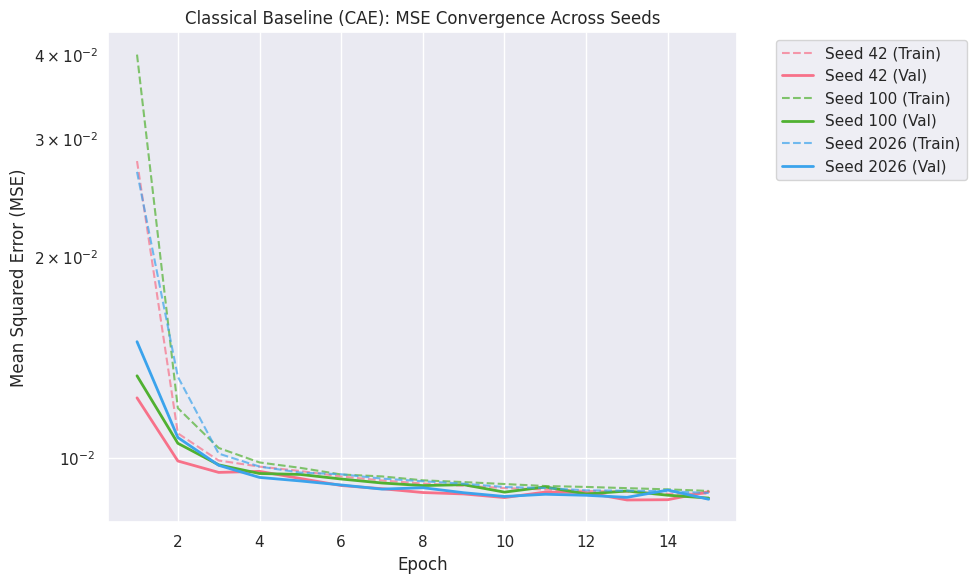

In [5]:
import sys
import os

# Bulletproof path injection ensures the Colab kernel can locate the src module
sys.path.append(os.path.abspath('.'))

from src.utils.viz import plot_training_logs

# Architecture-agnostic MSE plot
plot_training_logs(
    log_file_path="training_run.log",
    title="Classical Baseline (CAE): MSE Convergence Across Seeds"
)